# Importing python libraries to be used 

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(rc={"figure.figsize": (10, 6)})

# Loading datasets to be used
Add more datasets as needed

In [63]:
##Loading TFT datasets
##TFT_C_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_Challenger_MatchData.csv")
##TFT_D_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_Diamond_MatchData.csv")
##TFT_GM_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_GrandMaster_MatchData.csv")
##TFT_M_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_Master_MatchData.csv")
##TFT_P_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_Platinum_MatchData.csv")

PUBG_agg_stats_df = pd.read_csv("Datasets\\PUBG_Match_Data\\aggregate\\agg_match_stats_4.csv")

# Data Preprocessing for TFT

In [ ]:
TFT_C_Data_df = TFT_C_Data_df.drop(columns=['gameId','gameDuration'])
TFT_D_Data_df = TFT_D_Data_df.drop(columns=['gameId','gameDuration'])
TFT_GM_Data_df = TFT_GM_Data_df.drop(columns=['gameId','gameDuration'])
TFT_M_Data_df = TFT_M_Data_df.drop(columns=['gameId','gameDuration'])
TFT_P_Data_df = TFT_P_Data_df.drop(columns=['gameId','gameDuration'])

# Data Preprocessing for PUBG
The first EDA question we thought of given our data is trying to relate total survival time to a given squad size. Within PUBG players can enter matches with up to 3 other players, we wish to investigate if playing with others leads to an increased chance of survival. 

As a disclaimer, the PUBG dataset we are using gives the statistics for organizes its data into chunks of 5 categorized as the death statistics and the aggregate statistics. For the aggregate statistics 4 of the csv files exceeded the Git LFS file size limit Github allowed hence why only a size csv file is being used. 

Beginning preprocessing we drop all rows containing null values as well as columns that we won't be needing for analysis. 

In [64]:
PUBG_agg_stats_df = PUBG_agg_stats_df.dropna()
PUBG_agg_stats_df = PUBG_agg_stats_df.drop(columns=['date','game_size','match_id','match_mode','team_id','player_name'])

Next we convert the "player_survive_time" column to be measured in minutes rather than seconds.

In [65]:
PUBG_agg_stats_df['player_survive_time'] = PUBG_agg_stats_df['player_survive_time']/60
PUBG_agg_stats_df['player_survive_time'] = np.round(PUBG_agg_stats_df['player_survive_time'], decimals=2)

While this was discovered during EDA, retroactively, we shall put this step before it. There are several extremely high outlier values within the "player_survive_time" column. We attributed these values as encoding errors as they are statistically impossible.

In [59]:
print(PUBG_agg_stats_df['player_survive_time'].sort_values(ascending=False).head(10))

8912396     17680059.72
8912397     17680059.72
8912398     17680059.72
10549706    17679662.64
10549645    17679662.64
10549628    17679662.64
10549669    17679662.64
10549671    17679662.64
10549657    17679662.64
10549661    17679662.64
Name: player_survive_time, dtype: float64


To address we decided to drop these rows entirely based on the 99th percentile value

In [67]:
max = PUBG_agg_stats_df['player_survive_time'].quantile(0.99) #this returns 32.24 minutes which is a reasonable number as the average PUBG match does last around 20-30 minutes
PUBG_agg_stats_df = PUBG_agg_stats_df[PUBG_agg_stats_df['player_survive_time'] < max]

# Exploratory Data Analysis for PUBG 

<Axes: xlabel='party_size', ylabel='player_survive_time'>

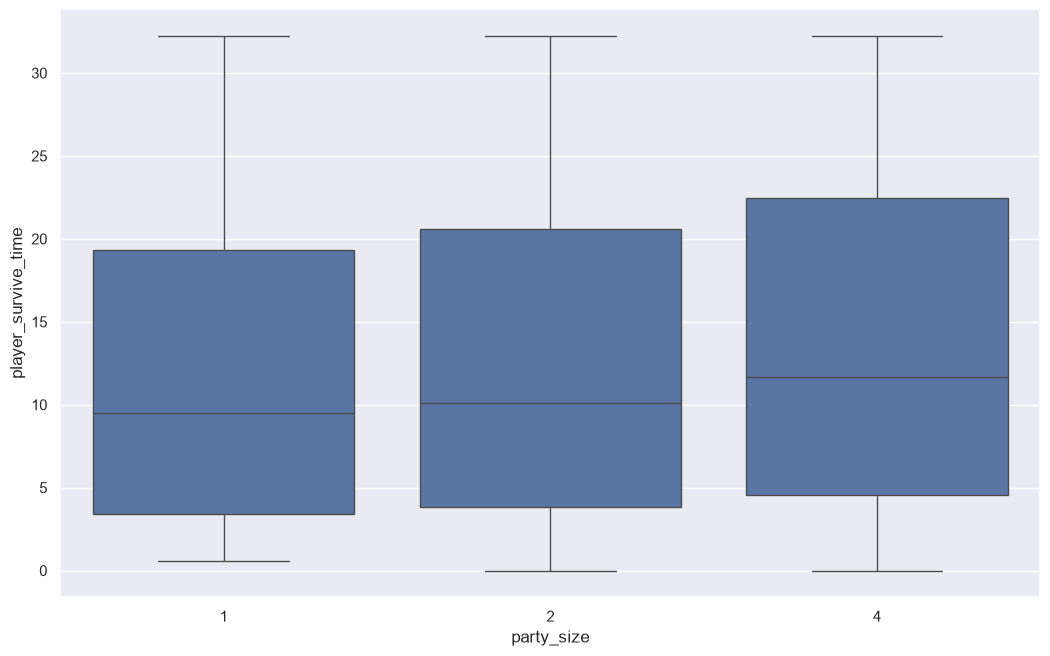

In [88]:
sns.boxplot(data=PUBG_agg_stats_df, x='party_size', y='player_survive_time')

<Axes: xlabel='party_size', ylabel='team_placement'>

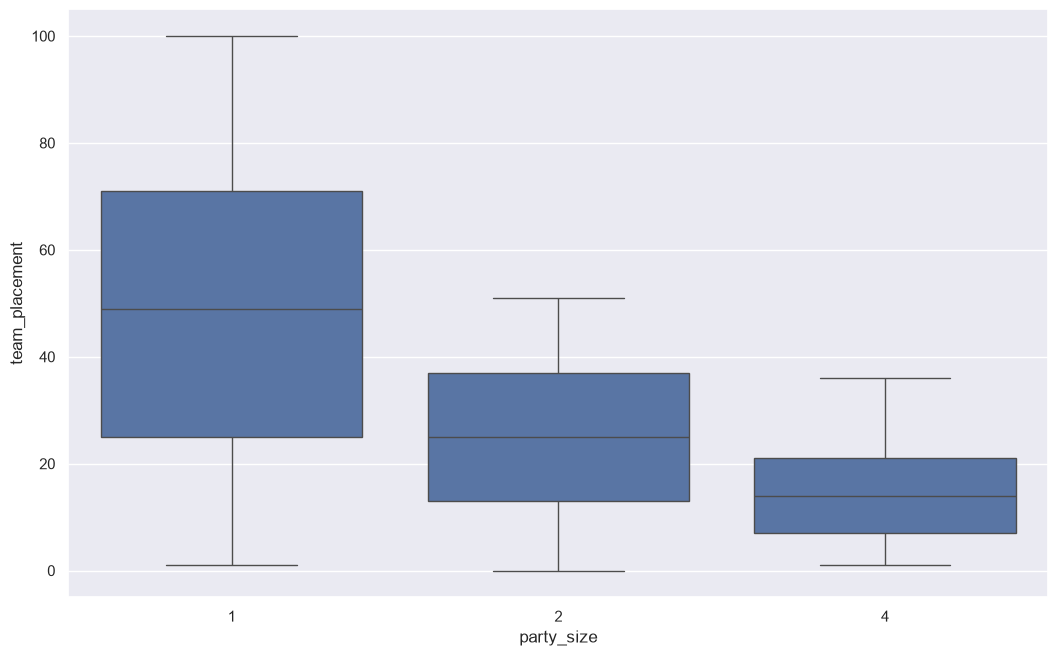

In [87]:
sns.boxplot(data=PUBG_agg_stats_df, x='party_size', y='team_placement')

<Axes: xlabel='team_placement', ylabel='party_size'>

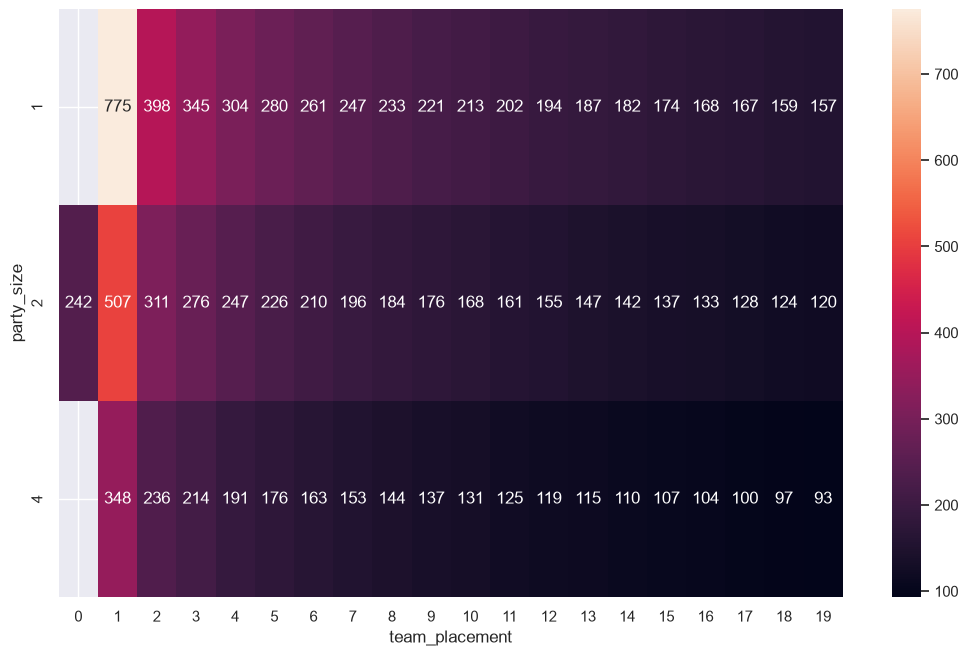

In [91]:
top = PUBG_agg_stats_df[PUBG_agg_stats_df['team_placement'] < 20]
heat = top.pivot_table(index='party_size',columns='team_placement',values='player_dmg',aggfunc='mean')

sns.heatmap(heat, annot=True, fmt='.0f')